# Fish correlation with pycnocline

/Users/Christian/miniforge3/envs/argo-tutorials/lib/python3.11/site-packages/gsw/stability.py:86: RuntimeWarning: divide by zero encountered in divide
  N2 = ((g_local**2) / (specvol_mid * db_to_pa * dp))


Number of fish files: 3
Total observations: 277
       temperature    salinity     depth_m  distance_to_pycnocline
count   277.000000  277.000000  277.000000              277.000000
mean     14.327928   18.335188    8.908303               -4.236049
std       0.674003    2.282548    0.993878                1.362351
min      11.559046   11.585350    5.000000              -10.629591
25%      14.061049   17.001290    8.500000               -4.660859
50%      14.389078   18.536171    9.000000               -4.093063
75%      14.767264   19.617648    9.500000               -3.531882
max      15.836219   25.533379   12.500000               -1.161495


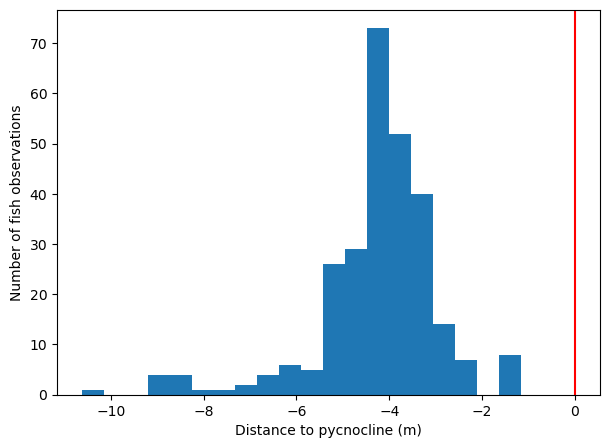

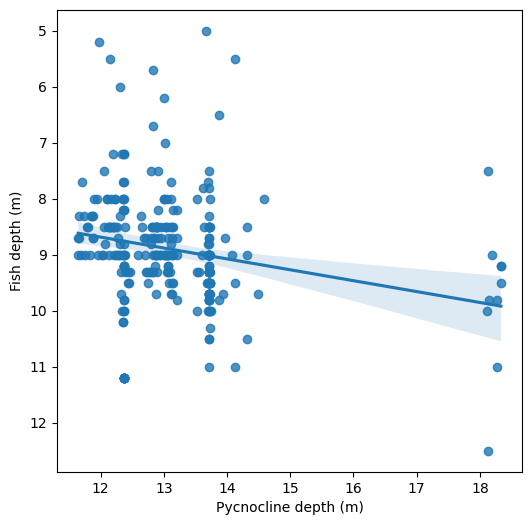


Fish depth vs pycnocline depth
r = 0.233
p = 8.893775578892203e-05

Mean distance to pycnocline: -4.24 m


In [30]:
import pandas as pd
import numpy as np
import glob
import re
import gsw
from geopy.distance import geodesic
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# DATA FOLDER
# ==========================================================

data_folder = "/Users/Christian/Library/Mobile Documents/com~apple~CloudDocs/University/DTU/Applied Ocean Observation Technologies/Fish project/CTD + fish obs"

# ==========================================================
# READ SEABIRD FILES
# ==========================================================

def read_cnv(filename):

    with open(filename, "r", encoding="latin1") as f:
        lines = f.readlines()

    # latitude
    lat_line = [l for l in lines if "NMEA Latitude" in l][0]
    lon_line = [l for l in lines if "NMEA Longitude" in l][0]

    lat_match = re.search(r'(\d+)\s+([\d.]+)\s+([NS])', lat_line)
    lon_match = re.search(r'(\d+)\s+([\d.]+)\s+([EW])', lon_line)

    lat_deg, lat_min, lat_dir = lat_match.groups()
    lon_deg, lon_min, lon_dir = lon_match.groups()

    lat = float(lat_deg) + float(lat_min)/60
    lon = float(lon_deg) + float(lon_min)/60

    if lat_dir == "S":
        lat *= -1
    if lon_dir == "W":
        lon *= -1

    # locate start of data
    start = [i for i, l in enumerate(lines) if "*END*" in l][0] + 1

    data = pd.read_csv(
        filename,
        skiprows=start,
        sep=r"\s+",
        header=None,
        engine="python"
    )

    # CHANGE THESE COLUMN NUMBERS IF NEEDED
    data.columns = [
        "depth_m",
        "salinity",
        "temperature",
        "flag"
    ]

    data["cast_file"] = filename
    data["cast_lat"] = lat
    data["cast_lon"] = lon

    return data

# ==========================================================
# LOAD ALL CTD FILES
# ==========================================================

files = glob.glob(data_folder + "/*.[cC][nN][vV]")

ctd = pd.concat(
    [read_cnv(f) for f in files],
    ignore_index=True
)

# ==========================================================
# KEEP DOWNCAST ONLY
# ==========================================================

profiles = []

for cast, profile in ctd.groupby("cast_file"):

    profile = profile.sort_values("depth_m")

    imax = profile["depth_m"].idxmax()

    profile = profile.loc[:imax]

    profiles.append(profile)

ctd = pd.concat(profiles)

# ==========================================================
# CALCULATE DENSITY USING TEOS-10
# ==========================================================

ctd["pressure"] = gsw.p_from_z(
    -ctd["depth_m"],
    ctd["cast_lat"]
)

ctd["SA"] = gsw.SA_from_SP(
    ctd["salinity"],
    ctd["pressure"],
    ctd["cast_lon"],
    ctd["cast_lat"]
)

ctd["CT"] = gsw.CT_from_t(
    ctd["SA"],
    ctd["temperature"],
    ctd["pressure"]
)

ctd["density"] = gsw.rho(
    ctd["SA"],
    ctd["CT"],
    ctd["pressure"]
)

# ==========================================================
# CALCULATE PYCNOCLINE USING MAXIMUM N²
# ==========================================================

pycnocline_depths = []

for cast, profile in ctd.groupby("cast_file"):

    profile = profile.sort_values("depth_m")

    profile = profile[profile["depth_m"] > 5]

    # smooth density
    rho = (
        profile["density"]
        .rolling(7, center=True)
        .mean()
        .dropna()
    )

    depth = profile.loc[rho.index, "depth_m"].values

    pressure = profile.loc[rho.index, "pressure"].values

    N2, p_mid = gsw.Nsquared(
        rho.values,
        pressure,
        profile["cast_lat"].iloc[0]
    )

    depth_mid = np.interp(
        p_mid,
        pressure,
        depth
    )

    pycnocline_depth = depth_mid[np.argmax(N2)]

    pycnocline_depths.append({
        "cast_file": cast,
        "pycnocline_depth": pycnocline_depth
    })

pycnocline_depths = pd.DataFrame(pycnocline_depths)

# ==========================================================
# LOAD FISH DATA
# ==========================================================

import glob
import os
import pandas as pd

fish_files = glob.glob(data_folder + "/*.csv")

fish_list = []

for f in fish_files:

    df = pd.read_csv(f)

    df["source_file"] = os.path.basename(f)

    fish_list.append(df)

fish = pd.concat(
    fish_list,
    ignore_index=True
)

print("Number of fish files:", len(fish_files))
print("Total observations:", len(fish))

fish["depth_m"] = (
    fish["depth_min_m"] +
    fish["depth_max_m"]
) / 2

# ==========================================================
# CTD LOCATIONS
# ==========================================================

cast_locations = (
    ctd[
        ["cast_file",
         "cast_lat",
         "cast_lon"]
    ]
    .drop_duplicates()
)

# ==========================================================
# FIND 3 NEAREST CTDS
# ==========================================================

from geopy.distance import geodesic

def nearest_casts(fish_row, cast_locations, n=3):

    fish_pos = (fish_row.lat, fish_row.lon)

    distances = []

    for _, row in cast_locations.iterrows():

        cast_pos = (
            row.cast_lat,
            row.cast_lon
        )

        d = geodesic(
            fish_pos,
            cast_pos
        ).km

        distances.append(d)

    temp = cast_locations.copy()
    temp["distance_km"] = distances

    return temp.sort_values("distance_km").head(n)


# ==========================================================
# INTERPOLATE T AND S TO FISH DEPTH
# ==========================================================

def interpolate_profile(profile, depth):

    T = np.interp(
        depth,
        profile.depth_m,
        profile.temperature
    )

    S = np.interp(
        depth,
        profile.depth_m,
        profile.salinity
    )

    return T, S


# ==========================================================
# ASSIGN CONDITIONS TO EACH FISH USING
# INVERSE-DISTANCE WEIGHTING OF 3 CLOSEST CASTS
# ==========================================================

temps = []
sals = []
pycs = []

for _, fish_row in fish.iterrows():

    nearest = nearest_casts(
        fish_row,
        cast_locations,
        n=3
    )

    temp_values = []
    sal_values = []
    pyc_values = []
    weights = []

    for _, cast in nearest.iterrows():

        profile = ctd[
            ctd.cast_file == cast.cast_file
        ]

        T, S = interpolate_profile(
            profile,
            fish_row.depth_m
        )

        pyc = (
            pycnocline_depths.loc[
                pycnocline_depths.cast_file ==
                cast.cast_file,
                "pycnocline_depth"
            ]
            .values[0]
        )

        # avoid division by zero
        distance = max(cast.distance_km, 0.001)

        weight = 1 / distance

        temp_values.append(T)
        sal_values.append(S)
        pyc_values.append(pyc)
        weights.append(weight)

    weights = np.array(weights)
    weights = weights / weights.sum()

    weighted_temp = np.sum(
        np.array(temp_values) * weights
    )

    weighted_sal = np.sum(
        np.array(sal_values) * weights
    )

    weighted_pyc = np.sum(
        np.array(pyc_values) * weights
    )

    temps.append(weighted_temp)
    sals.append(weighted_sal)
    pycs.append(weighted_pyc)

fish["temperature"] = temps
fish["salinity"] = sals
fish["pycnocline_depth"] = pycs

# ==========================================================
# DISTANCE TO PYCNOCLINE
# ==========================================================

fish["distance_to_pycnocline"] = (
    fish["depth_m"]
    - fish["pycnocline_depth"]
)

# ==========================================================
# SUMMARY STATISTICS
# ==========================================================

print(
    fish[
        ["temperature",
         "salinity",
         "depth_m",
         "distance_to_pycnocline"]
    ].describe()
)

# ==========================================================
# HISTOGRAM OF DISTANCE TO PYCNOCLINE
# ==========================================================

plt.figure(figsize=(7,5))

plt.hist(
    fish["distance_to_pycnocline"],
    bins=20
)

plt.axvline(
    0,
    color="red"
)

plt.xlabel("Distance to pycnocline (m)")
plt.ylabel("Number of fish observations")

plt.show()

# ==========================================================
# FISH DEPTH VS PYCNOCLINE DEPTH
# ==========================================================

plt.figure(figsize=(6,6))

sns.regplot(
    data=fish,
    x="pycnocline_depth",
    y="depth_m"
)

plt.gca().invert_yaxis()

plt.xlabel("Pycnocline depth (m)")
plt.ylabel("Fish depth (m)")

plt.show()

# ==========================================================
# CORRELATION TEST
# ==========================================================

r, p = pearsonr(
    fish["depth_m"],
    fish["pycnocline_depth"]
)

print()
print("Fish depth vs pycnocline depth")
print("r =", round(r,3))
print("p =", p)

# ==========================================================
# MEAN DISTANCE FROM PYCNOCLINE
# ==========================================================

print()
print(
    "Mean distance to pycnocline:",
    round(fish["distance_to_pycnocline"].mean(),2),
    "m"
)

# Difference between days

In [31]:
import glob
import os

data_folder = "/Users/Christian/Library/Mobile Documents/com~apple~CloudDocs/University/DTU/Applied Ocean Observation Technologies/Fish project/CTD + fish obs"

fish_files = glob.glob(data_folder + "/*.csv")

print("Fish files found:")
for f in fish_files:
    print(os.path.basename(f))


print("\nObservations per file:")
print(fish["source_file"].value_counts())

print("\nDepth summary:")
print(fish["depth_m"].describe())

print(
    fish[
        ["temperature",
         "salinity",
         "depth_m"]
    ].describe()
)

print(
    f"Temperature = {fish.temperature.mean():.2f} ± {fish.temperature.std():.2f} °C"
)

print(
    f"Salinity = {fish.salinity.mean():.2f} ± {fish.salinity.std():.2f} PSU"
)

print(
    f"Depth = {fish.depth_m.mean():.2f} ± {fish.depth_m.std():.2f} m"
)

Fish files found:
fish_events_0610.csv
fish_events_0611.csv
fish_events_0612.csv

Observations per file:
source_file
fish_events_0612.csv    186
fish_events_0611.csv     73
fish_events_0610.csv     18
Name: count, dtype: int64

Depth summary:
count    277.000000
mean       8.908303
std        0.993878
min        5.000000
25%        8.500000
50%        9.000000
75%        9.500000
max       12.500000
Name: depth_m, dtype: float64
       temperature    salinity     depth_m
count   277.000000  277.000000  277.000000
mean     14.327928   18.335188    8.908303
std       0.674003    2.282548    0.993878
min      11.559046   11.585350    5.000000
25%      14.061049   17.001290    8.500000
50%      14.389078   18.536171    9.000000
75%      14.767264   19.617648    9.500000
max      15.836219   25.533379   12.500000
Temperature = 14.33 ± 0.67 °C
Salinity = 18.34 ± 2.28 PSU
Depth = 8.91 ± 0.99 m


##### Boxplot of variables across the three days

       depth_m                  temperature                        salinity  \
          mean       std median        mean       std     median       mean   
day                                                                           
0610  8.938889  1.016996    9.0   14.337904  0.486250  14.295026  18.325342   
0611  9.143836  0.929155    9.2   14.331888  0.679802  14.332618  18.452564   
0612  8.812903  1.005738    9.0   14.325408  0.690023  14.426811  18.290074   

                           
           std     median  
day                        
0610  1.975703  18.666040  
0611  2.236133  18.563272  
0612  2.336782  18.518073  


/var/folders/_w/s199ztdj3xb7m_6ykdw7znrw0000gn/T/ipykernel_74404/3065100375.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(labels, rotation=45)
/var/folders/_w/s199ztdj3xb7m_6ykdw7znrw0000gn/T/ipykernel_74404/3065100375.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(labels, rotation=45)
/var/folders/_w/s199ztdj3xb7m_6ykdw7znrw0000gn/T/ipykernel_74404/3065100375.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(labels, rotation=45)


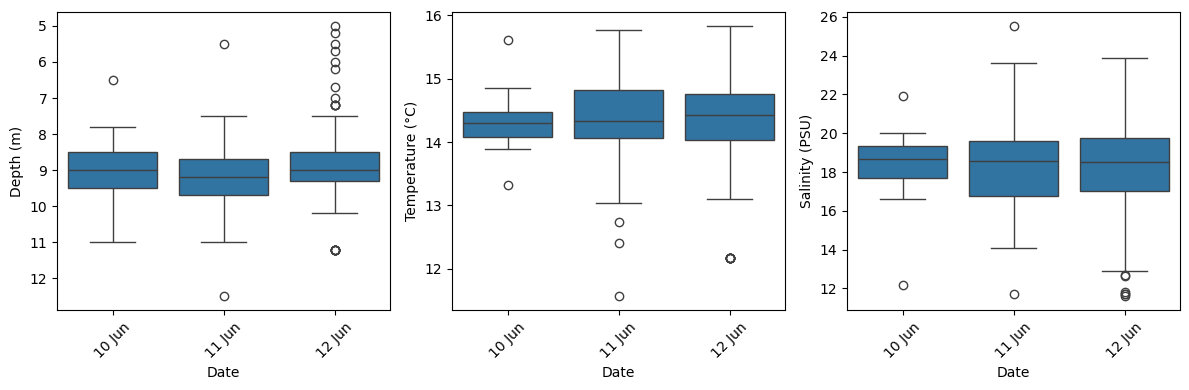

In [ ]:
fish["day"] = (
    fish["source_file"]
    .str.extract(r'(\d{4})')
)

summary = (
    fish.groupby("day")
    .agg({
        "depth_m":["mean","std","median"],
        "temperature":["mean","std","median"],
        "salinity":["mean","std","median"]
    })
)

print(summary)

import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,3, figsize=(12,4))

sns.boxplot(data=fish, x="day", y="depth_m", ax=ax[0])
ax[0].invert_yaxis()  # <— add this
ax[0].set_ylabel("Depth (m)")
ax[0].set_xlabel("Date")

sns.boxplot(data=fish, x="day", y="temperature", ax=ax[1])
ax[1].set_ylabel("Temperature (°C)")
ax[1].set_xlabel("Date")

sns.boxplot(data=fish, x="day", y="salinity", ax=ax[2])
ax[2].set_ylabel("Salinity (PSU)")
ax[2].set_xlabel("Date")

# Manual x-axis labels
labels = ["10 Jun", "11 Jun", "12 Jun"]

for a in ax:

    a.set_xticklabels(labels, rotation=45)

plt.tight_layout()

plt.show()

##### Shapiro-Wilk test for normality (assumption)

If p < 0.05, the variable is not normally distributed.

In [47]:
from scipy.stats import shapiro

for variable in ["depth_m","temperature","salinity"]:

    print("\n", variable)

    for d in fish["day"].unique():

        p = shapiro(
            fish.loc[
                fish.day == d,
                variable
            ]
        )[1]

        print(d, "p =", round(p,4))


 depth_m
0610 p = 0.7347
0611 p = 0.0005
0612 p = 0.0

 temperature
0610 p = 0.1451
0611 p = 0.0001
0612 p = 0.0

 salinity
0610 p = 0.007
0611 p = 0.1645
0612 p = 0.0


##### Kruskal-Wallis test for differences between days

Non-parametric because most data isn't normally distributed

Interpretation

* p < 0.05 → significant difference among days.
* p ≥ 0.05 → no evidence that fish occupied different conditions.

In [49]:

from scipy.stats import kruskal

for variable in ["depth_m","temperature","salinity"]:

    groups = [
        fish.loc[fish.day == d, variable]
        for d in sorted(fish.day.unique())
    ]

    H, p = kruskal(*groups)

    print(variable)
    print("H =", round(H,3))
    print("p =", p)
    print()

depth_m
H = 7.14
p = 0.028156003602678514

temperature
H = 0.488
p = 0.7833907457598985

salinity
H = 0.064
p = 0.9687281597199336



##### Dunn's post-hoc test
to determine which days differ

In [50]:

import scikit_posthocs as sp

sp.posthoc_dunn(
    fish,
    val_col="depth_m",
    group_col="day",
    p_adjust="bonferroni"
)

,0610,0611,0612
0610,1.0,1.00000,1.00000
0611,1.0,1.00000,0.02384
0612,1.0,0.02384,1.00000


In [57]:
kruskal(
    fish[fish["day"]=="0610"]["distance_to_pycnocline"],
    fish[fish["day"]=="0611"]["distance_to_pycnocline"],
    fish[fish["day"]=="0612"]["distance_to_pycnocline"]
)

import scikit_posthocs as sp

# Dunn post-hoc test (with Bonferroni correction)
dunn = sp.posthoc_dunn(
    fish,
    val_col="distance_to_pycnocline",
    group_col="day",
    p_adjust="bonferroni"
)

print(dunn)

          0610      0611      0612
0610  1.000000  0.362825  0.002106
0611  0.362825  1.000000  0.005774
0612  0.002106  0.005774  1.000000


In [51]:
print(fish["distance_to_pycnocline"].describe())

r, p = pearsonr(
    fish["depth_m"],
    fish["pycnocline_depth"]
)

print(r, p)

count    277.000000
mean      -4.236049
std        1.362351
min      -10.629591
25%       -4.660859
50%       -4.093063
75%       -3.531882
max       -1.161495
Name: distance_to_pycnocline, dtype: float64
0.23326492115437816 8.893775578892203e-05


# Difference between individuals and schools of fish

##### Summary of individual vs schools

                depth_m                            temperature             \
                  count      mean       std median       count       mean   
category                                                                    
individual_fish     220  8.830909  0.998697    9.0         220  14.414435   
school               57  9.207018  0.923862    9.3          57  13.994038   

                                     salinity                                  
                      std     median    count       mean       std     median  
category                                                                       
individual_fish  0.648017  14.445951      220  18.062874  2.278145  18.317146  
school           0.673698  14.079908       57  19.386225  1.991446  19.529183  


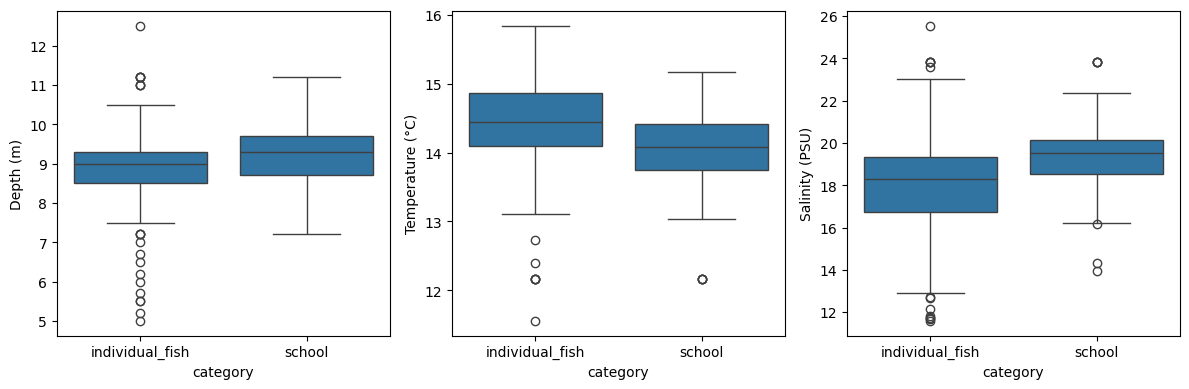

In [62]:

summary = fish.groupby("category")[[

    "depth_m",

    "temperature",

    "salinity"

]].agg(["count", "mean", "std", "median"])

print(summary)



import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,3, figsize=(12,4))

sns.boxplot(data=fish,
            x="category",
            y="depth_m",
            ax=ax[0])

sns.boxplot(data=fish,
            x="category",
            y="temperature",
            ax=ax[1])

sns.boxplot(data=fish,
            x="category",
            y="salinity",
            ax=ax[2])

ax[0].set_ylabel("Depth (m)")
ax[1].set_ylabel("Temperature (°C)")
ax[2].set_ylabel("Salinity (PSU)")

plt.tight_layout()
plt.show()

##### Mann-Whitney U-test

In [37]:
from scipy.stats import mannwhitneyu

individuals = fish[fish["category"]=="individual_fish"]
schools = fish[fish["category"]=="school"]

for variable in ["depth_m", "temperature", "salinity"]:

    U, p = mannwhitneyu(
        individuals[variable],
        schools[variable],
        alternative="two-sided"
    )

    print(variable)
    print("U =", U)
    print("p =", p)
    print()

#     p < 0.05 → individuals and schools occupied significantly different environments.

depth_m
U = 4712.0
p = 0.003670324791351175

temperature
U = 8825.5
p = 2.1334073602247744e-06

salinity
U = 3833.5
p = 6.196407687368837e-06

